In [3]:
!pip install ultralytics
!pip install ensemble-boxes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.1 MB/s eta 0:00:00


In [4]:
!git clone https://github.com/ultralytics/yolov5
!pip install -r yolov5/requirements.txt

Cloning into 'yolov5'...
remote: Enumerating objects: 17842, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 17842 (delta 29), reused 6 (delta 6), pack-reused 17794 (from 2)
Receiving objects: 100% (17842/17842), 16.97 MiB | 16.83 MiB/s, done.
Resolving deltas: 100% (12157/12157), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 5.6 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0


In [5]:
from ultralytics.utils.downloads import download

download("https://ultralytics.com/assets/brain-tumor.zip", dir="datasets")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Unzipping datasets/brain-tumor.zip to /content/datasets/brain-tumor...: 100% ━━━━━━━━━━━━ 2225/2225 9.0Kfiles/s 0.2s


In [6]:
import zipfile

with zipfile.ZipFile("datasets/brain-tumor.zip", 'r') as zip_ref:
    zip_ref.extractall("datasets/")

In [7]:
import os

print(os.listdir("datasets/brain-tumor/images/train")[:5])

['00352_93.jpg', '00184_127.jpg', '88 (3).jpg', '00159_133.jpg', '00186_207.jpg']


In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from ensemble_boxes import weighted_boxes_fusion

In [15]:
data_yaml = """
train: /content/datasets/images/train
val: /content/datasets/images/val

nc: 2
names: ['tumor','non-tumor']
"""

with open("brain_tumor_fixed.yaml", "w") as f:
    f.write(data_yaml)

In [16]:
import os
os.environ["WANDB_DISABLED"] = "true"

!python yolov5/train.py \
--img 640 \
--batch 16 \
--epochs 20 \
--data brain_tumor_fixed.yaml \
--weights yolov5s.pt \
--name yolov5_brain_tumor \
--exist-ok

wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-03-11 15:56:14.274246: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773244574.295006    6172 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773244574.301912    6172 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773244574.320717    6172 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773244574.320744    6172 computation_placer.cc:177] computation placer already registere

In [12]:
model = YOLO("yolov8n.pt")

model.train(
    data="datasets/brain-tumor/brain-tumor.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    name="yolov8_brain_tumor"
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/brain-tumor/brain-tumor.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_brain_tumor, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b1626581ca0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [21]:
import torch
from ultralytics import YOLO

# Load YOLOv5 model
model_v5 = torch.hub.load(
    'ultralytics/yolov5',
    'custom',
    path='yolov5/runs/train/yolov5_brain_tumor/weights/best.pt'
)

# Load YOLOv8 model
model_v8 = YOLO("runs/detect/yolov8_brain_tumor/weights/best.pt")

/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /root/.cache/torch/hub/master.zip


YOLOv5 🚀 2026-3-11 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 


In [25]:
image_path = "/content/datasets/images/val/val_1 (73).jpg"

pred_v5 = model_v5(image_path)
pred_v8 = model_v8(image_path)

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):



image 1/1 /content/datasets/images/val/val_1 (73).jpg: 640x640 1 negative, 1 positive, 14.1ms
Speed: 5.1ms preprocess, 14.1ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


In [35]:

def extract_boxes_v5(result):
    boxes = result.xyxy[0][:, :4].cpu().numpy()
    scores = result.xyxy[0][:, 4].cpu().numpy()
    labels = result.xyxy[0][:, 5].cpu().numpy().astype(int)
    return boxes, scores, labels


def extract_boxes_v8(result):
    boxes = result.boxes.xyxy.cpu().numpy()
    scores = result.boxes.conf.cpu().numpy()
    labels = result.boxes.cls.cpu().numpy().astype(int)
    return boxes, scores, labels


boxes_v5, scores_v5, labels_v5 = extract_boxes_v5(pred_v5)
boxes_v8, scores_v8, labels_v8 = extract_boxes_v8(pred_v8[0])

In [36]:
# automatically choose a validation image
val_images = os.listdir("/content/datasets/images/val")
image_path = "/content/datasets/images/val/" + val_images[0]

img = cv2.imread(image_path)
h, w = img.shape[:2]


def normalize(boxes):
    boxes_norm = []
    for b in boxes:
        x1, y1, x2, y2 = b
        boxes_norm.append([x1/w, y1/h, x2/w, y2/h])
    return boxes_norm


boxes_v5 = normalize(boxes_v5)
boxes_v8 = normalize(boxes_v8)


In [40]:
import os

val_images = os.listdir("/content/datasets/images/val")

image_path = "/content/datasets/images/val/" + val_images[0]

print("Using image:", image_path)

pred_v5 = model_v5(image_path)
pred_v8 = model_v8(image_path)

Using image: /content/datasets/images/val/val_1 (73).jpg

image 1/1 /content/datasets/images/val/val_1 (73).jpg: 640x640 1 negative, 1 positive, 9.2ms
Speed: 2.9ms preprocess, 9.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


In [41]:

boxes_list = [boxes_v5, boxes_v8]
scores_list = [scores_v5.tolist(), scores_v8.tolist()]
labels_list = [labels_v5.tolist(), labels_v8.tolist()]

boxes, scores, labels = weighted_boxes_fusion(
    boxes_list,
    scores_list,
    labels_list,
    weights=[1, 1],
    iou_thr=0.5,
    skip_box_thr=0.3
)



In [42]:
boxes_final = []

for b in boxes:
    x1, y1, x2, y2 = b
    boxes_final.append([x1*w, y1*h, x2*w, y2*h])



In [52]:

%matplotlib inline

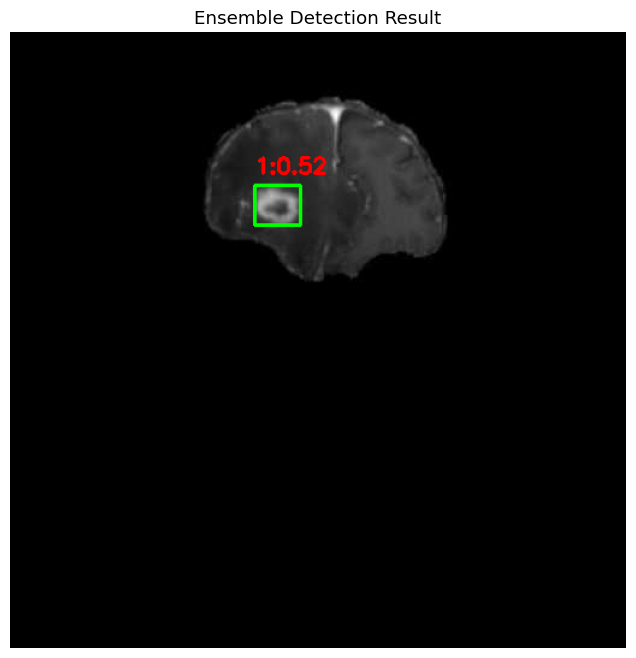

In [54]:
from IPython.display import clear_output
import cv2
import matplotlib.pyplot as plt

clear_output(wait=True)

img = cv2.imread(image_path)

if img is None:
    print("Image not loaded!")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    for box, score, label in zip(boxes_final, scores, labels):

        x1, y1, x2, y2 = map(int, box)

        cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

        cv2.putText(
            img,
            f"{int(label)}:{score:.2f}",
            (x1, y1-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255,0,0),
            2
        )

    plt.figure(figsize=(8,8))
    plt.imshow(img)
    plt.title("Ensemble Detection Result")
    plt.axis("off")
    plt.show()